# 03. Avaliação de Modelos 


In [1]:
import sys
sys.path.append("../src")
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

import utils as ut

RANDOM_STATE = 42
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": "#444444", "axes.grid": True,
    "grid.color": "#e5e5e5", "grid.linewidth": 0.8, "font.size": 11,
})


In [2]:
train, test = ut.load_processed("../data/processed")
full = ut.make_full_series(train, test)
full_dates = full["Date"].values

origins = ut.walkforward_origins(len(train), len(test), max_h=max(ut.HORIZONS))
FEATURE_COLS = ut.feature_columns()
print(f"{len(FEATURE_COLS)} features:", FEATURE_COLS)


19 features: ['lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', 'lag_10', 'lag_20', 'roll_mean_5', 'roll_std_5', 'roll_mean_10', 'roll_std_10', 'roll_mean_20', 'roll_std_20', 'return_1', 'return_5', 'dow', 'day', 'month', 'volume_lag1']


## Engenharia de features e alvos diretos por horizonte

In [3]:
feat_train = ut.build_features(train)
feat_train = ut.build_direct_targets(feat_train, horizons=ut.HORIZONS)

target_cols = [f"target_h{h}" for h in ut.HORIZONS]
feat_train_clean = feat_train.dropna(subset=FEATURE_COLS + target_cols).reset_index(drop=True)
print(f"Linhas antes da limpeza: {len(feat_train)} | depois (sem NaN de lag/target): {len(feat_train_clean)}")
feat_train_clean[["Date"] + FEATURE_COLS[:4] + target_cols].head(3)


Linhas antes da limpeza: 1345 | depois (sem NaN de lag/target): 1322


,Date,lag_1,lag_2,lag_3,lag_4,target_h1,target_h2,target_h3
0,2013-01-31,18.200001,19.110001,19.370001,19.610001,18.459999,18.00,18.08
1,2013-02-01,18.080000,18.200001,19.110001,19.370001,18.000000,18.08,17.60
2,2013-02-04,18.459999,18.080000,18.200001,19.110001,18.080000,17.60,17.50


## Correlação das features com o alvo

Antes de comparar algoritmos, vale checar se as features construídas carregam relação com o que está sendo previsto (target_h1) e se muitas delas repetem a mesma informação. A correlação de Pearson de cada feature com target_h1 é calculada primeiro, e depois a correlação entre as próprias features, para identificar pares muito correlacionados (|correlação| > 0,9).

In [4]:
corr_target = feat_train_clean[FEATURE_COLS + ["target_h1"]].corr()["target_h1"].drop("target_h1")
corr_target = corr_target.reindex(corr_target.abs().sort_values(ascending=False).index)
corr_target

lag_1           0.990683
lag_2           0.985665
roll_mean_5     0.984597
lag_3           0.980834
roll_mean_10    0.976590
lag_4           0.975935
lag_5           0.971027
roll_mean_20    0.960512
lag_10          0.947209
lag_20          0.898911
roll_std_10     0.285388
roll_std_5      0.257658
roll_std_20     0.248279
volume_lag1    -0.188373
return_5        0.114459
return_1        0.051197
month           0.044373
day            -0.008537
dow            -0.000494
Name: target_h1, dtype: float64

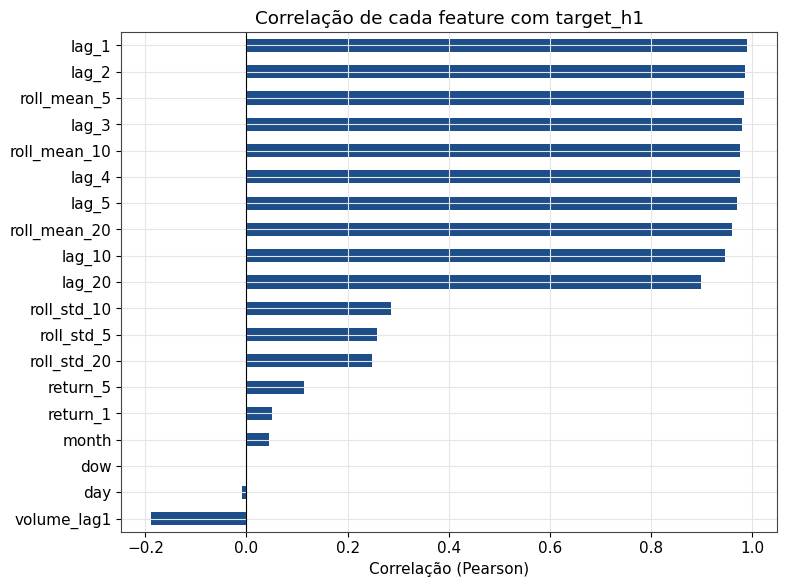

In [5]:
fig, ax = plt.subplots(figsize=(8, 6))
corr_target.sort_values().plot(kind="barh", ax=ax, color=ut.PALETTE["ml_ridge"])
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Correlação de cada feature com target_h1")
ax.set_xlabel("Correlação (Pearson)")
fig.tight_layout()
plt.show()

In [6]:
feat_corr = feat_train_clean[FEATURE_COLS].corr()

pares = (
    feat_corr.where(np.triu(np.ones(feat_corr.shape), k=1).astype(bool))
    .stack()
    .rename("corr")
    .reset_index()
)
pares.columns = ["feature_1", "feature_2", "corr"]
pares = pares.reindex(pares["corr"].abs().sort_values(ascending=False).index)
pares[pares["corr"].abs() > 0.9].reset_index(drop=True)

,feature_1,feature_2,corr
0,lag_3,roll_mean_5,0.998144
1,lag_2,roll_mean_5,0.997161
2,lag_4,roll_mean_5,0.997121
3,lag_5,roll_mean_10,0.995998
4,roll_mean_5,roll_mean_10,0.995877
5,lag_1,lag_2,0.995231
6,lag_4,lag_5,0.995220
7,lag_2,lag_3,0.995219
8,lag_3,lag_4,0.995200
9,lag_4,roll_mean_10,0.994999


## Seleção do algoritmo por horizonte

In [7]:
N_VAL = 40
candidates = {
    "ridge": Ridge(alpha=5.0),
    "random_forest": RandomForestRegressor(n_estimators=400, max_depth=6, min_samples_leaf=3, random_state=RANDOM_STATE),
    "gradient_boosting": GradientBoostingRegressor(n_estimators=300, max_depth=3, learning_rate=0.03, random_state=RANDOM_STATE),
}

inner_train = feat_train_clean.iloc[:-N_VAL]
inner_val = feat_train_clean.iloc[-N_VAL:]

best_algo_per_h = {}
val_scores = []

for h in ut.HORIZONS:
    ycol = f"target_h{h}"
    scores_h = {}
    for name, model in candidates.items():
        model.fit(inner_train[FEATURE_COLS], inner_train[ycol])
        pred = model.predict(inner_val[FEATURE_COLS])
        m = ut.regression_metrics(inner_val[ycol], pred)
        scores_h[name] = m
        val_scores.append({"horizon": h, "algoritmo": name, **m})
    best_algo_per_h[h] = min(scores_h, key=lambda k: scores_h[k]["MAPE"])

val_scores_df = pd.DataFrame(val_scores)
print("Melhor algoritmo por horizonte:", best_algo_per_h)
val_scores_df.pivot(index="algoritmo", columns="horizon", values="MAPE").round(2)


Melhor algoritmo por horizonte: {1: 'ridge', 2: 'ridge', 3: 'ridge'}


horizon,1,2,3
algoritmo,,,
gradient_boosting,5.87,6.96,7.75
random_forest,5.57,6.88,8.09
ridge,3.24,4.33,5.36


## Retreino final e geração das previsões walk-forward

O modelo escolhido é retreinado com todo o histórico disponível e gera previsões nas mesmas 17 origens. A cada previsão, utiliza apenas os dados reais disponíveis até aquele momento.

In [8]:
final_models = {}
for h in ut.HORIZONS:
    ycol = f"target_h{h}"
    algo_name = best_algo_per_h[h]
    model = candidates[algo_name].__class__(**candidates[algo_name].get_params())
    model.fit(feat_train_clean[FEATURE_COLS], feat_train_clean[ycol])
    final_models[h] = (algo_name, model)
    print(f"h={h}: modelo final = {algo_name}")


h=1: modelo final = ridge
h=2: modelo final = ridge
h=3: modelo final = ridge


In [9]:
rows_ml = []

for origin in origins:
    origin_date = full_dates[origin]
    history_raw = full.iloc[: origin + 1][["Date", "Close", "Volume"]]
    history_feat = ut.build_features(history_raw)
    x_row = history_feat.iloc[[-1]][FEATURE_COLS]

    for h in ut.HORIZONS:
        algo_name, model = final_models[h]
        pred = model.predict(x_row)[0]
        ut.append_predictions(rows_ml, origin_date, full_dates, full["Close"].values, origin, h, f"ml_{algo_name}", pred)

results_ml = pd.DataFrame(rows_ml)
results_ml.to_csv("../results/predictions_ml.csv", index=False)

metrics_ml = ut.summarize_by_horizon(results_ml)
metrics_ml.to_csv("../results/metrics_ml.csv", index=False)
metrics_ml.pivot(index="model", columns="horizon", values="MAPE").round(2)


horizon,1,2,3
model,,,
ml_ridge,6.43,5.6,7.71


## Comparação walk-forward de todos os candidatos de ML

Só o Ridge seguiu para o retreino final, por ter vencido a validação interna nos três horizontes. Para efeito de comparação, os outros dois candidatos (Random Forest e Gradient Boosting) são treinados do mesmo jeito, com as 19 features e todo o histórico de treino, e avaliados nas mesmas 17 origens walk-forward, sem passar pela seleção interna.

In [10]:
outros_final_models = {}
for h in ut.HORIZONS:
    ycol = f"target_h{h}"
    for name, base_model in candidates.items():
        if name == "ridge":
            continue
        model = base_model.__class__(**base_model.get_params())
        model.fit(feat_train_clean[FEATURE_COLS], feat_train_clean[ycol])
        outros_final_models[(h, name)] = model

rows_outros = []
for origin in origins:
    origin_date = full_dates[origin]
    history_raw = full.iloc[: origin + 1][["Date", "Close", "Volume"]]
    history_feat = ut.build_features(history_raw)
    x_row = history_feat.iloc[[-1]][FEATURE_COLS]

    for h in ut.HORIZONS:
        for name in ["random_forest", "gradient_boosting"]:
            model = outros_final_models[(h, name)]
            pred = model.predict(x_row)[0]
            ut.append_predictions(rows_outros, origin_date, full_dates, full["Close"].values, origin, h, f"ml_{name}", pred)

results_ml = pd.concat([results_ml, pd.DataFrame(rows_outros)], ignore_index=True)
results_ml.to_csv("../results/predictions_ml.csv", index=False)

metrics_ml = ut.summarize_by_horizon(results_ml)
metrics_ml.to_csv("../results/metrics_ml.csv", index=False)
metrics_ml.pivot(index="model", columns="horizon", values="MAPE").round(2)


horizon,1,2,3
model,,,
ml_gradient_boosting,9.41,9.88,11.13
ml_random_forest,7.43,5.99,8.29
ml_ridge,6.43,5.60,7.71


## Prophet

In [11]:
from prophet import Prophet
import logging
logging.getLogger("cmdstanpy").setLevel(logging.ERROR)
logging.getLogger("prophet").setLevel(logging.ERROR)
import contextlib, io

rows_prophet = []
for origin in origins:
    origin_date = full_dates[origin]
    history = full.iloc[: origin + 1][["Date", "Close"]].rename(columns={"Date": "ds", "Close": "y"})
    model = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
    with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
        model.fit(history)
        future = model.make_future_dataframe(periods=max(ut.HORIZONS), freq="B")
        forecast = model.predict(future)
    preds = forecast["yhat"].values[-max(ut.HORIZONS):]
    for h in ut.HORIZONS:
        ut.append_predictions(rows_prophet, origin_date, full_dates, full["Close"].values, origin, h, "prophet", preds[h - 1])

results_ml = pd.concat([results_ml, pd.DataFrame(rows_prophet)], ignore_index=True)
results_ml.to_csv("../results/predictions_ml.csv", index=False)

metrics_ml = ut.summarize_by_horizon(results_ml)
metrics_ml.to_csv("../results/metrics_ml.csv", index=False)
metrics_ml.pivot(index="model", columns="horizon", values="MAPE").round(2)

Importing plotly failed. Interactive plots will not work.


horizon,1,2,3
model,,,
ml_gradient_boosting,9.41,9.88,11.13
ml_random_forest,7.43,5.99,8.29
ml_ridge,6.43,5.60,7.71
prophet,35.89,36.98,39.12


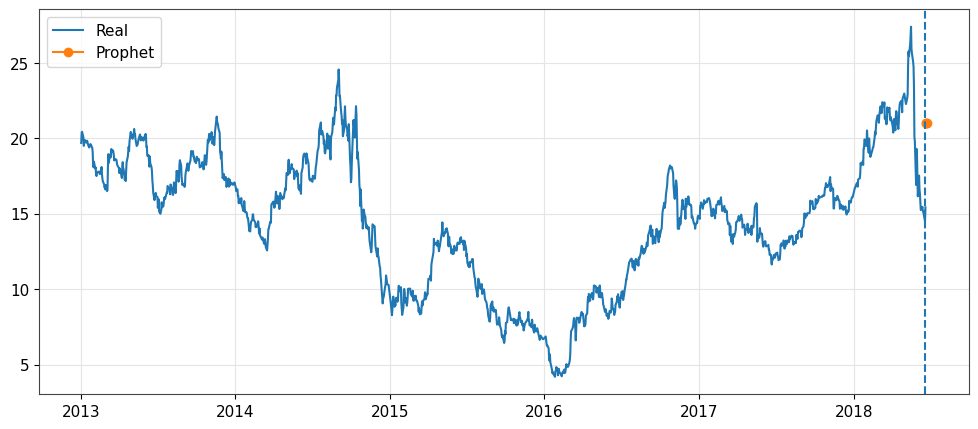

In [12]:
plt.figure(figsize=(12, 5))

plt.plot(
    history["ds"],
    history["y"],
    label="Real"
)

plt.plot(
    forecast["ds"].iloc[-3:],
    forecast["yhat"].iloc[-3:],
    marker="o",
    label="Prophet"
)

plt.axvline(
    history["ds"].iloc[-1],
    linestyle="--"
)

plt.legend()
plt.show()

O Prophet está superestimando o preço porque prioriza a tendência global do histórico e não captura bem a forte queda recente da série.


## Interpretação do modelo (h = 1)


Algoritmo escolhido para h=1: ridge


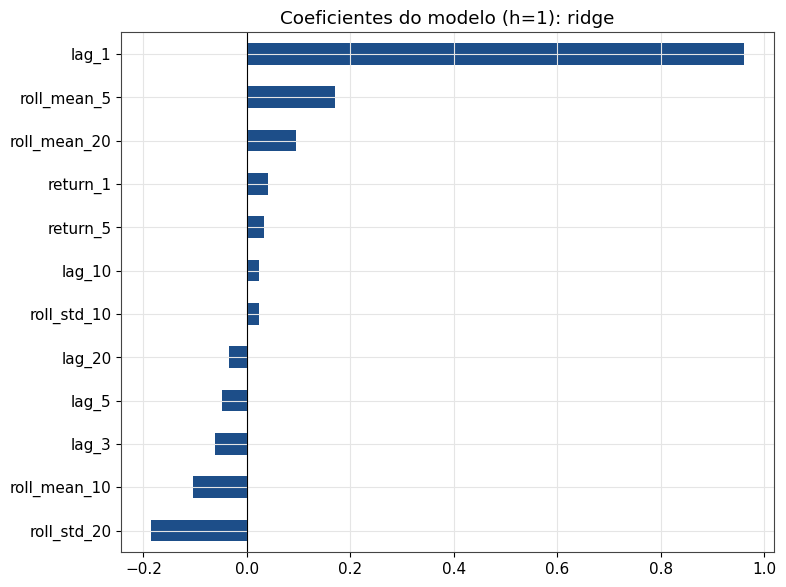

lag_1           0.960849
roll_std_20    -0.185136
roll_mean_5     0.169602
roll_mean_10   -0.103265
roll_mean_20    0.094195
lag_3          -0.061140
lag_5          -0.047715
return_1        0.040466
lag_20         -0.034268
return_5        0.033839
dtype: float64

In [13]:
algo_h1, model_h1 = final_models[1]
print("Algoritmo escolhido para h=1:", algo_h1)

if hasattr(model_h1, "coef_"):
    imp = pd.Series(model_h1.coef_, index=FEATURE_COLS).sort_values(key=np.abs, ascending=False)
    titulo = f"Coeficientes do modelo (h=1): {algo_h1}"
elif hasattr(model_h1, "feature_importances_"):
    imp = pd.Series(model_h1.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)
    titulo = f"Importância das variáveis (h=1): {algo_h1}"

fig, ax = plt.subplots(figsize=(8, 6))
imp.head(12).sort_values().plot(kind="barh", ax=ax, color=ut.PALETTE["ml_ridge"])
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title(titulo)
fig.tight_layout()
plt.show()

imp.head(10)


## Erro (MAPE) por horizonte, modelo escolhido e Prophet

ml_ridge: h=1 6,43%, h=2 5,60%, h=3 7,71%. prophet: h=1 35,89%, h=2 36,98%, h=3 39,12%.

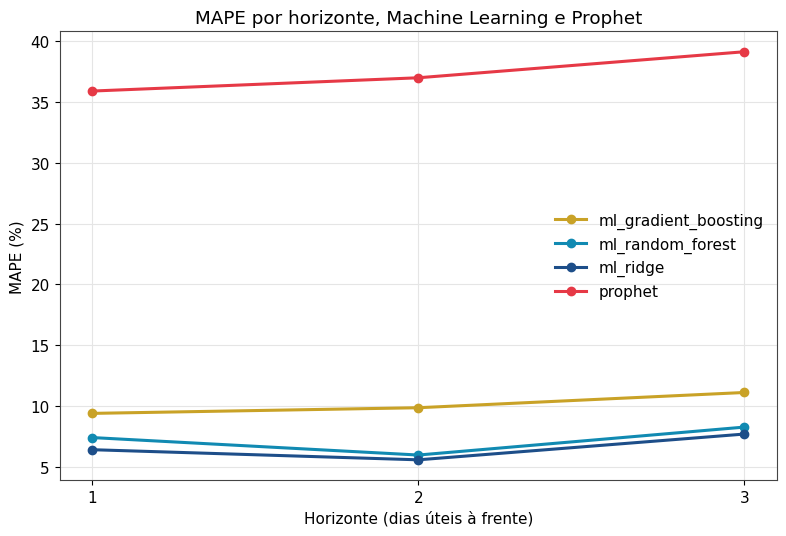

In [14]:
fig, ax = plt.subplots(figsize=(8, 5.5))
for model, g in metrics_ml.groupby("model"):
    g = g.sort_values("horizon")
    ax.plot(g["horizon"], g["MAPE"], marker="o", linewidth=2.2, color=ut.PALETTE.get(model, "#D9782D"), label=model)
ax.set_xticks(ut.HORIZONS)
ax.set_xlabel("Horizonte (dias úteis à frente)")
ax.set_ylabel("MAPE (%)")
ax.set_title("MAPE por horizonte, Machine Learning e Prophet")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()
